In [1]:
import sys
sys.path.append('../')
from utils.MultiLabelPredictor import MultilabelPredictor
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.spatial.distance import cosine
import seaborn as sns
from scipy.optimize import nnls

/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
def update_W_nnls_masked(V, H, mask):
    """
    Calcola W dato V e H fisso usando NNLS riga per riga,
    con vincolo: alcune componenti di W fissate a 0 (mask=0).

    V: (n_samples, n_features)
    H: (n_components, n_features)
    mask: (n_samples, n_components), valori binari (1=attiva, 0=fissata a 0)

    Ritorna:
    W: (n_samples, n_components)
    """
    n_samples, n_features = V.shape
    n_components = H.shape[0]
    W = np.zeros((n_samples, n_components))

    for i in range(n_samples):
        active_idx = np.where(mask[i] == 1)[0]   # firme attive per sample i
        if len(active_idx) == 0:
            continue  # nessuna firma attiva -> tutto zero

        A = H[active_idx].T   # (n_features, n_active)
        b = V[i, :]
        w_active, _ = nnls(A, b)

        # reinserisci nei posti giusti
        W[i, active_idx] = w_active

    return W

from sklearn.metrics.pairwise import cosine_similarity

def evaluate_results(W, W_predicted):
    # R^2
    r2 = r2_score(W, W_predicted)

    # MSE
    mse = mean_squared_error(W, W_predicted)
    
    # MAE
    mae = mean_absolute_error(W, W_predicted)

    # Cosine similarity per riga (paziente)
    cos_similarity_matrix = cosine_similarity(W, W_predicted)
    cos_similarity_per_patient = np.diag(cos_similarity_matrix)
    mean_cos_similarity = np.mean(cos_similarity_per_patient)

    print(f"R2: {r2},\nMSE: {mse},\nMAE: {mae},\nCosine similarity: {mean_cos_similarity}")
    return cos_similarity_per_patient


In [3]:
sampling_size = '0.02'

In [4]:
V = np.array(pd.read_csv(f'../simulations/data2/run_1/trinucleotides_counts_sampling_{sampling_size}.csv').iloc[:, 1:].values)  # N x 96
active_signatures = pd.read_csv('../simulations/ground_truth/bin_exposures.csv').iloc[:, 1:].astype(int).values  # N x 29
alpha = np.array(pd.read_csv('../simulations/ground_truth/exposures.csv').iloc[:, 1:].values)  # N x 29
beta = np.array(pd.read_csv('../simulations/ground_truth/signatures.csv').iloc[:, 1:].values)

In [5]:
## Importing the ground truth
sampling_name = f'trinucleotides_counts_sampling_{sampling_size}'
new_base_path = f'../models/saved_models/default/Predictor-{sampling_size}'

pred_mutation_count = pd.read_csv(f'../simulations/data2/run_1/{sampling_name}.csv', index_col=0)
# aggiorna i path per ogni label
predictor = MultilabelPredictor.load(new_base_path)
for label in predictor.labels:
    predictor.predictors[label] = os.path.join(new_base_path, f'Predictor_{label}')
    
predictions = np.array(predictor.predict(pred_mutation_count))
W = update_W_nnls_masked(V = V, H = beta, mask = predictions)

Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S1 (SBS1 - 0.99) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)
Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S2 (SBS2 - 0.99) ...
Predicting with TabularPredictor for label: S3 (SBS3 - 0.97) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)
Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


...

Predicting with TabularPredictor for label: S27 (SBS88 - 0.92) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S28 (SBS92 - 0.95) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S29 (SBS97 - 0.95) ...


In [6]:
columns = np.array(pd.read_csv('../simulations/ground_truth/signatures.csv').iloc[:,0])

In [7]:
W_df = pd.DataFrame(W)
W_df.columns = columns
W_df

,S1 (SBS1 - 0.99),S2 (SBS2 - 0.99),S3 (SBS3 - 0.97),S4 (SBS4 - 0.98),S5 (SBS5 - 0.98),S6 (SBS7a - 1.00),S7 (SBS7b - 0.96),S8 (SBS8 - 0.92),S9 (SBS9 - 0.94),S10 (SBS10a - 1.00),...,S20 (SBS22 - 0.99),S21 (SBS23 - 0.94),S22 (SBS26 - 0.94),S23 (SBS28 - 0.96),S24 (SBS31 - 0.98),S25 (SBS32 - 0.94),S26 (SBS44 - 0.97),S27 (SBS88 - 0.92),S28 (SBS92 - 0.95),S29 (SBS97 - 0.95)
0,16.191643,19.538045,118.499755,17.091448,22.669710,0.000000,0.0,47.318227,0.0,0.0,...,9.345065,0.000000,0.0,0.000000,17.197455,0.000000,0.0,0.000000,0.000000,0.0
1,45.780093,0.000000,0.000000,0.000000,3.579240,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,7.839509,0.000000,0.0
2,0.976287,0.000000,8.053664,1.267272,5.317110,6.164189,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,5.099529,0.0,6.114263,0.000000,0.0
3,2.704519,8.636531,20.024803,10.772860,0.000000,5.302086,0.0,28.263395,0.0,0.0,...,0.000000,5.583824,0.0,5.439187,0.000000,0.000000,0.0,0.000000,10.722812,0.0
4,9.567576,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,8.384362,12.481556,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18114,28.953007,0.368185,0.306769,0.000000,6.644539,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.458377,14.260957,0.0
18115,6.698655,0.534772,7.381176,0.000000,7.545520,0.920525,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,2.577928,0.0
18116,6.920290,0.000000,0.000000,0.000000,1.175187,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
18117,10.830853,7.484356,5.821122,0.000000,15.063344,2.040781,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,8.165817,0.000000,0.0


In [8]:
sig_profiler_assignment = pd.read_csv(f'../results/sigProfilerAssignment/spa_{sampling_name}/Assignment_Solution_Activities.txt', sep='\t', index_col=0)
sig_prof_prediction = np.array(sig_profiler_assignment)
sig_prof_prediction

array([[  0,  27, 288, ...,   0,   0,   0],
       [ 51,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,  21,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,  12,   0, ...,  41,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(18119, 29))

In [9]:
musical_df = pd.read_csv(f'../results/musical/musical_preidction_{sampling_size}.txt', index_col=0).T
musical_prediction = np.array(musical_df)
musical_prediction

array([[ 16.1084613 ,  19.24952867, 145.19131296, ...,   0.        ,
          0.        ,   9.87801408],
       [ 45.20105961,   0.        ,   0.        , ...,   5.70641901,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   6.35257626,
          0.        ,   0.18137286],
       ...,
       [  3.00834072,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  8.70948489,   7.9923295 ,   7.27441442, ...,  11.01568934,
          0.        ,   3.20004203],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]], shape=(18119, 29))

In [15]:
cos_similarity_with_prediction = evaluate_results(alpha, W)

cos_sim_sig_prof = evaluate_results(alpha, sig_prof_prediction)

cos_sim_musical = evaluate_results(alpha, musical_prediction)

R2: -0.007210439186028441,
MSE: 228933580.3847068,
MAE: 792.0313299850114,
Cosine similarity: 0.8341730452117313
R2: -0.003626715333004171,
MSE: 229068850.92956066,
MAE: 792.0308669859927,
Cosine similarity: 0.7189009043130177
R2: -0.006217311530064605,
MSE: 228889592.83648428,
MAE: 792.6759489454508,
Cosine similarity: 0.786490120369698


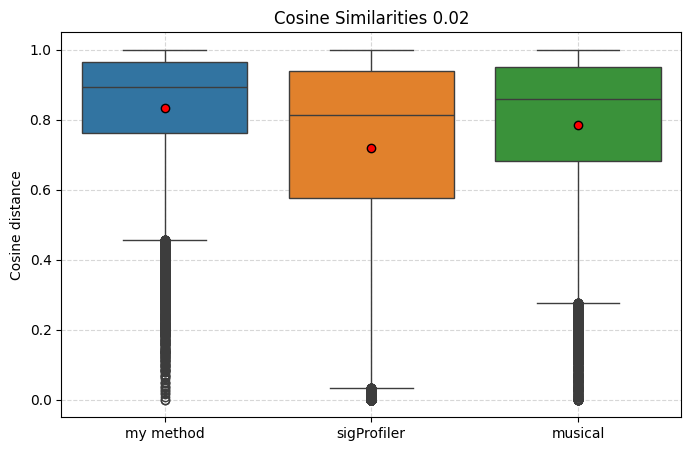

In [ ]:
cos_dists = [cos_similarity_with_prediction, cos_sim_sig_prof, cos_sim_musical]
labels = ['my method', 'sigProfiler', 'musical']
plt.figure(figsize=(8,5))
sns.boxplot(data=cos_dists, showmeans=True, meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.ylabel("Cosine similarities")
plt.title(f"Cosine Similarities {sampling_size}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

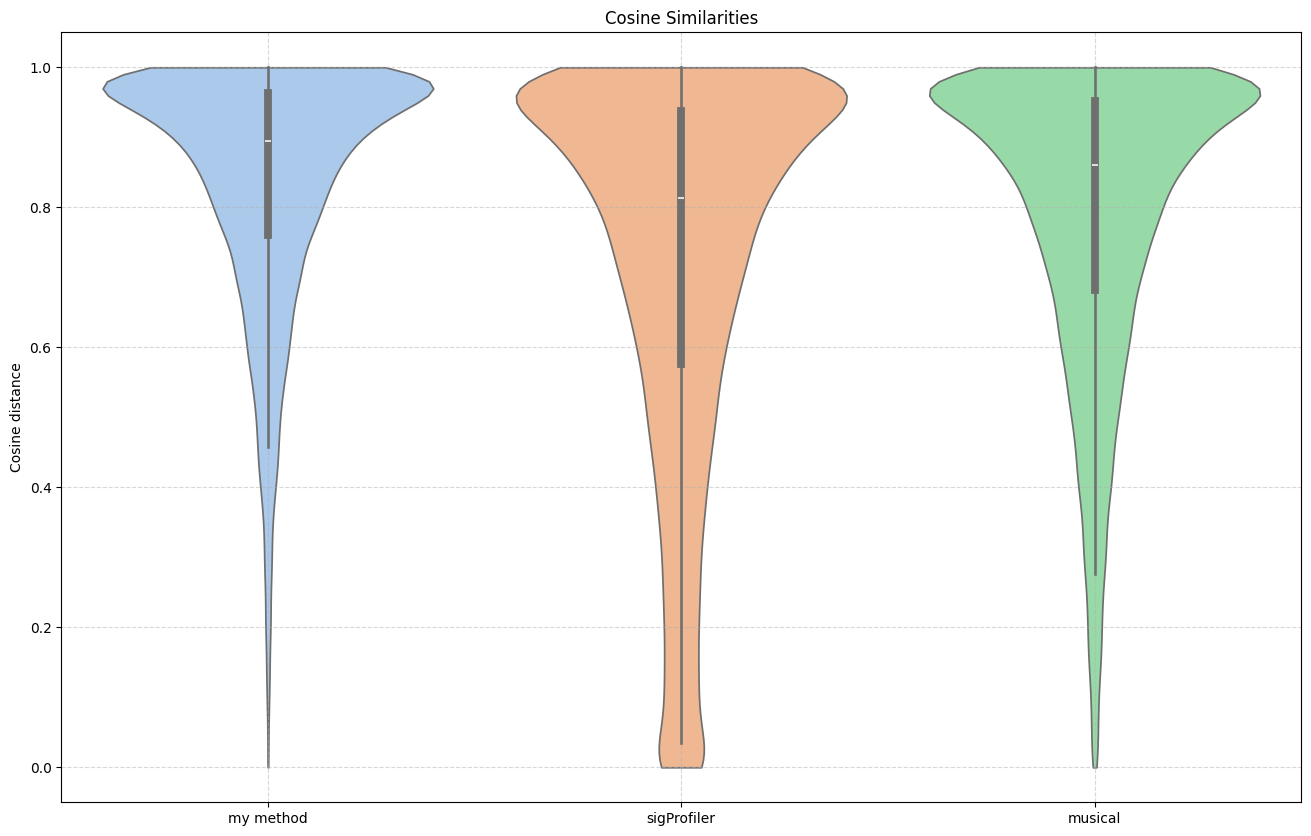

In [ ]:
plt.figure(figsize=(16, 10))
sns.violinplot(data=cos_dists, inner="box", cut=0, palette="pastel")
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.ylabel("Cosine similarities")
plt.title("Cosine Similarities")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()